# Statistical Anomaly Detection System

## Notebook 04: Multivariate Anomaly Detection

### Purpose

This notebook identifies anomalous observations by considering all pollutant variables simultaneously.

### Objectives

- Analyze multivariate structure
- Detect unusual observations
- Quantify anomaly severity
- Visualize anomaly patterns

### Expected Outcome

A multivariate anomaly detection framework capable of identifying observations that appear normal individually but unusual collectively.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest

import os

os.makedirs("images", exist_ok=True)

In [2]:
df = pd.read_csv(
    "Air Quality Data in India.csv",
    encoding="latin1",
    low_memory=False
)

pollutants = [
    "so2",
    "no2",
    "rspm",
    "spm"
]

air_quality = df[pollutants].copy()

for col in pollutants:

    air_quality[col] = (
        air_quality[col]
        .fillna(
            air_quality[col].median()
        )
    )

air_quality.head()

,so2,no2,rspm,spm
0,4.8,17.4,84.0,181.0
1,3.1,7.0,84.0,181.0
2,6.2,28.5,84.0,181.0
3,6.3,14.7,84.0,181.0
4,4.7,7.5,84.0,181.0


## Isolation Forest

Isolation Forest identifies anomalies by isolating observations that differ substantially from the majority of the dataset.

The method is particularly effective for multivariate anomaly detection.

In [3]:
model = IsolationForest(
    contamination=0.01,
    random_state=42
)

model.fit(
    air_quality
)

IsolationForest(contamination=0.01, random_state=42)

In [4]:
predictions = model.predict(
    air_quality
)

air_quality["anomaly"] = predictions

air_quality.head()

,so2,no2,rspm,spm,anomaly
0,4.8,17.4,84.0,181.0,1
1,3.1,7.0,84.0,181.0,1
2,6.2,28.5,84.0,181.0,1
3,6.3,14.7,84.0,181.0,1
4,4.7,7.5,84.0,181.0,1


In [5]:
anomaly_summary = (
    air_quality["anomaly"]
    .value_counts()
)

anomaly_summary

,count
anomaly,
1,9109
-1,93


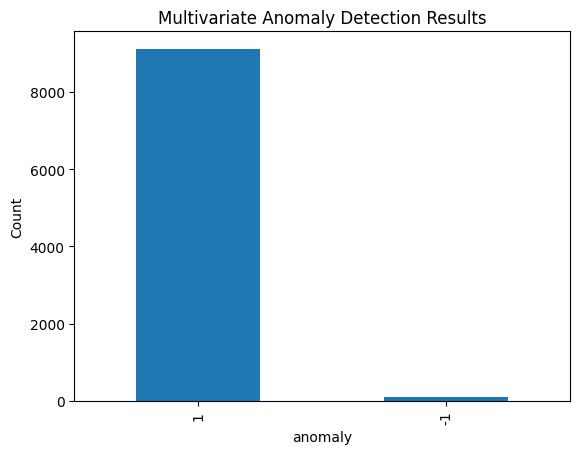

In [6]:
anomaly_summary.plot(
    kind="bar"
)

plt.title(
    "Multivariate Anomaly Detection Results"
)

plt.ylabel(
    "Count"
)

plt.savefig(
    "images/multivariate_anomaly_counts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
air_quality["anomaly_score"] = (
    model.decision_function(
        air_quality[pollutants]
    )
)

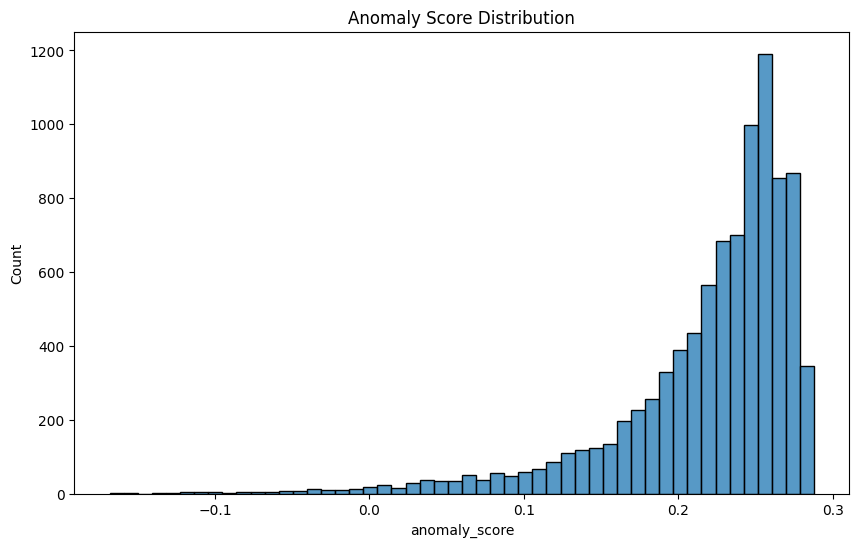

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(
    air_quality["anomaly_score"],
    bins=50
)

plt.title(
    "Anomaly Score Distribution"
)

plt.savefig(
    "images/anomaly_score_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

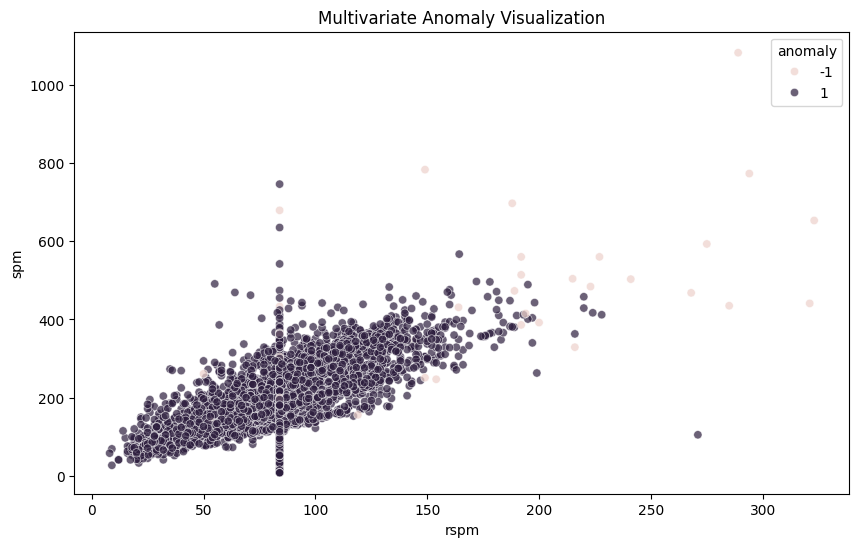

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=air_quality.sample(
        5000,
        random_state=42
    ),
    x="rspm",
    y="spm",
    hue="anomaly",
    alpha=0.7
)

plt.title(
    "Multivariate Anomaly Visualization"
)

plt.savefig(
    "images/multivariate_anomaly_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [10]:
air_quality.to_csv(
    "multivariate_anomaly_results.csv",
    index=False
)

## Findings

The multivariate anomaly detection framework successfully identified observations exhibiting unusual pollutant patterns.

Unlike univariate methods, the approach considers relationships among multiple pollutants simultaneously, allowing more sophisticated anomaly identification.

The resulting anomaly scores provide a quantitative basis for environmental risk monitoring and decision support.